In [1]:
#노트북이 코랩에서 실행 중인지 체크합니다.

import sys
if 'google.colab' in sys.modules:
  !echo 'debconf debconf/frontend select Noniteractive' | \
  debconf-set-selections

  # 나눔 폰트를 설치합니다.
  !sudo apt-get -qq -y install fonts-nanum
  import matplotlib.font_manager as fm
  font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
  for fpath in font_files:
    fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Noniteractive
debconf: (Can't locate Debconf/FrontEnd/Noniteractive.pm in @INC (you may need to install the Debconf::FrontEnd::Noniteractive module) (@INC contains: /etc/perl /usr/local/lib/x86_64-linux-gnu/perl/5.34.0 /usr/local/share/perl/5.34.0 /usr/lib/x86_64-linux-gnu/perl5/5.34 /usr/share/perl5 /usr/lib/x86_64-linux-gnu/perl-base /usr/lib/x86_64-linux-gnu/perl/5.34 /usr/share/perl/5.34 /usr/local/lib/site_perl) at (eval 17) line 2, <> line 1.)
debconf: falling back to frontend: Noninteractive
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['figure.dpi']=100

,월별 방한 외래관광객 (1975-2024),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,"Visitor Arrivals by Month, 1975-2024",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,연 도,계,성장률,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
4,Year,Total(명),Change(%),Jan.,Feb.,Mar.,Apr.,May,Jun.,Jul.,Aug.,Sep.,Oct.,Nov.,Dec.


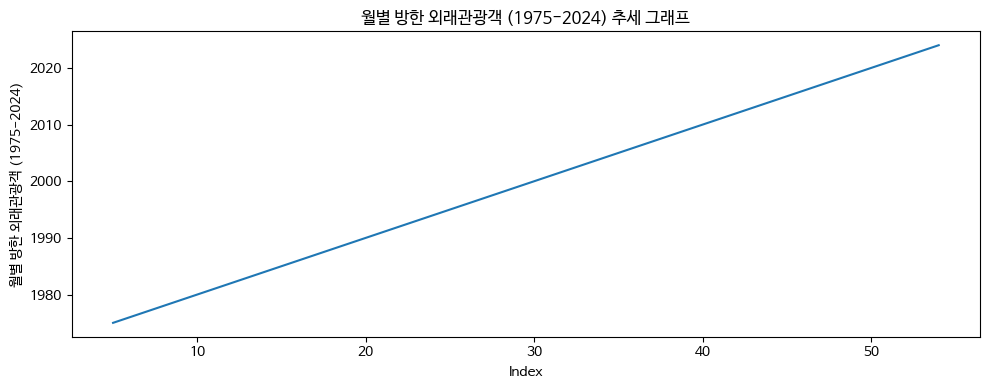

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Load Excel file
path = "/content/연도별통계(1975-2024).xlsx"
df = pd.read_excel(path)

# 2. Display first rows
display(df.head())

# 3. Identify numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# 4. If no numeric columns detected, force conversion
if len(numeric_cols) == 0:
    df_coerced = df.apply(pd.to_numeric, errors='coerce')
    numeric_cols = df_coerced.select_dtypes(include='number').columns.tolist()
else:
    df_coerced = df

# 5. Plot first numeric column
plt.figure(figsize=(10, 4))

if len(numeric_cols) > 0:
    ycol = numeric_cols[0]
    plt.plot(df_coerced[ycol])
    plt.xlabel("Index")
    plt.ylabel(ycol)
    plt.title(f"{ycol} 추세 그래프")
    plt.tight_layout()
    plt.show()
else:
    plt.title("숫자형 데이터가 없어 시각화를 생성할 수 없습니다.")
    plt.tight_layout()
    plt.show()


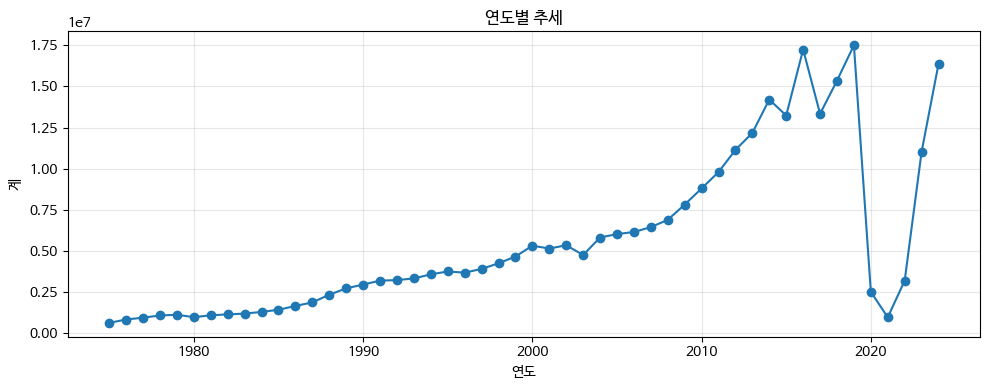

/tmp/ipython-input-3180828823.py:51: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


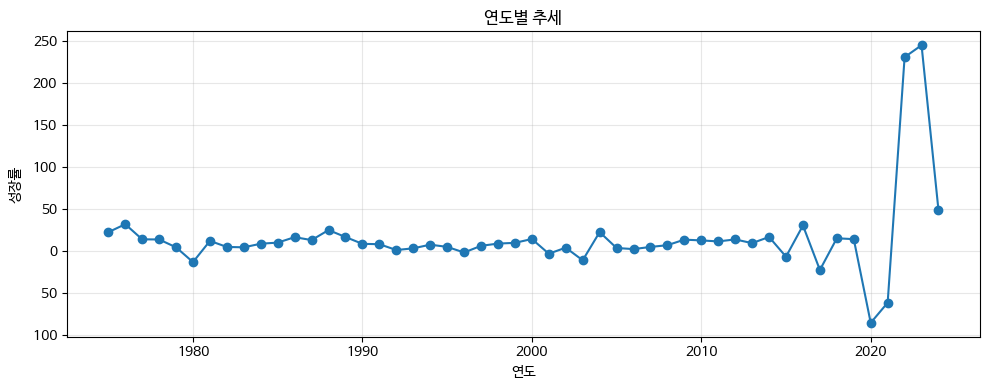

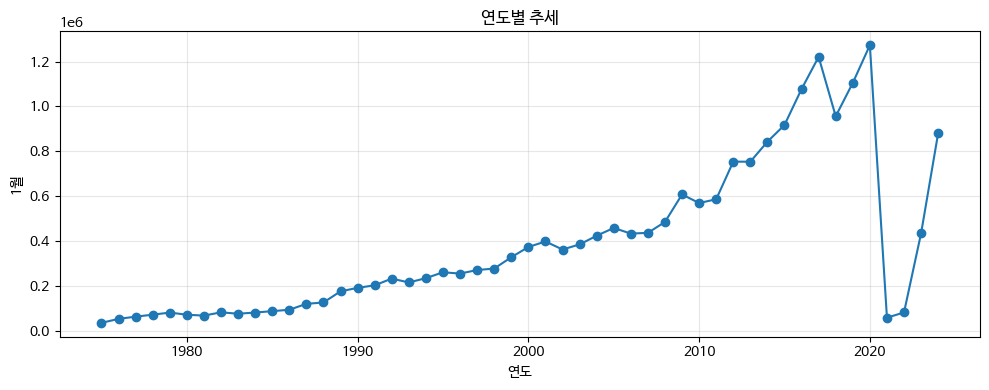

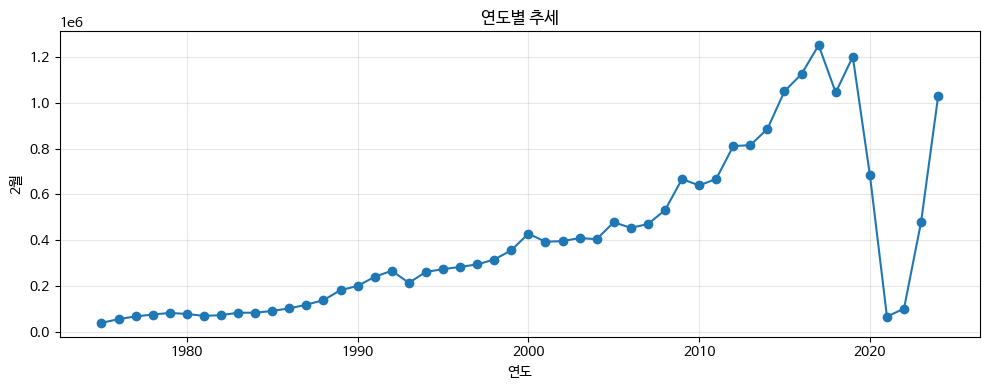

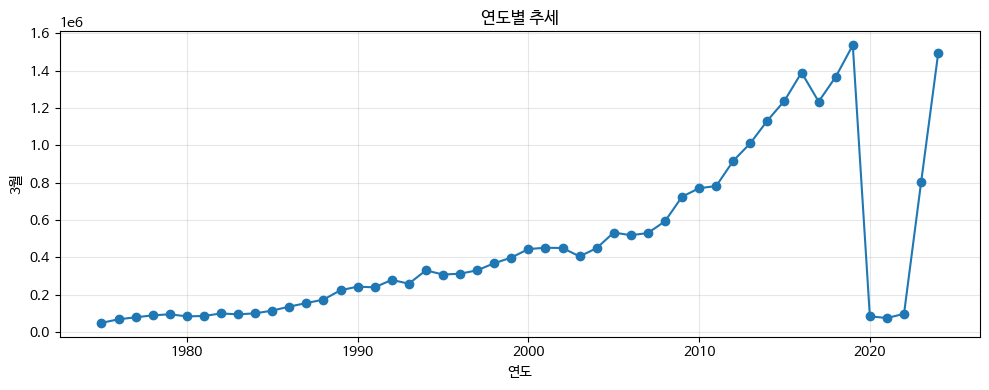

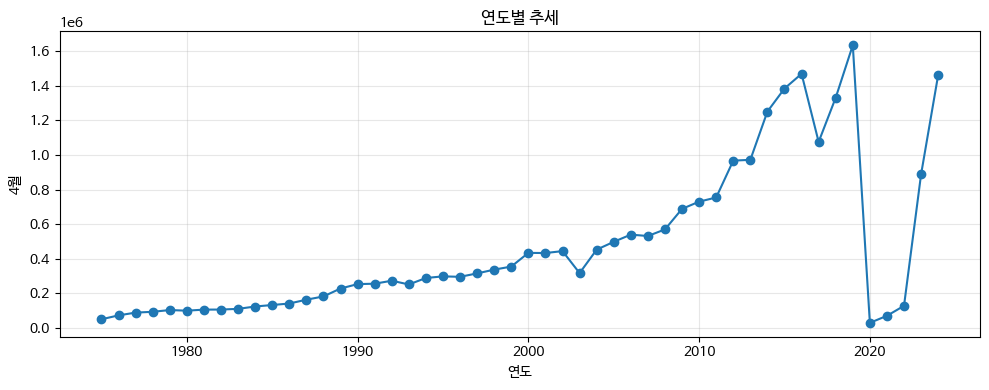

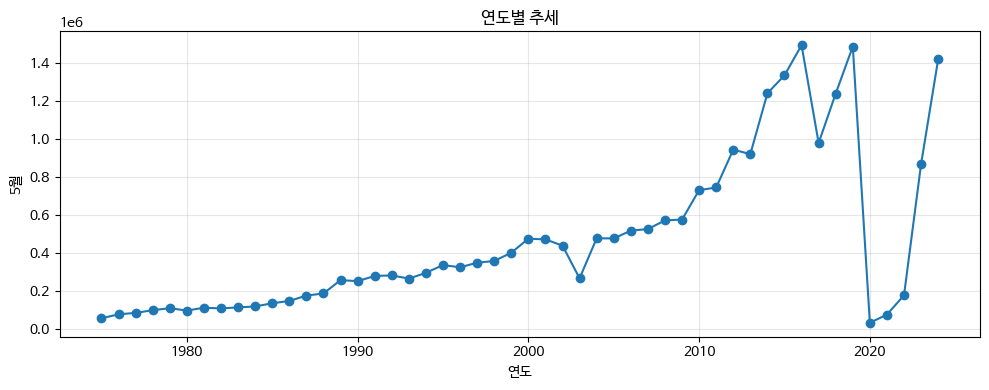

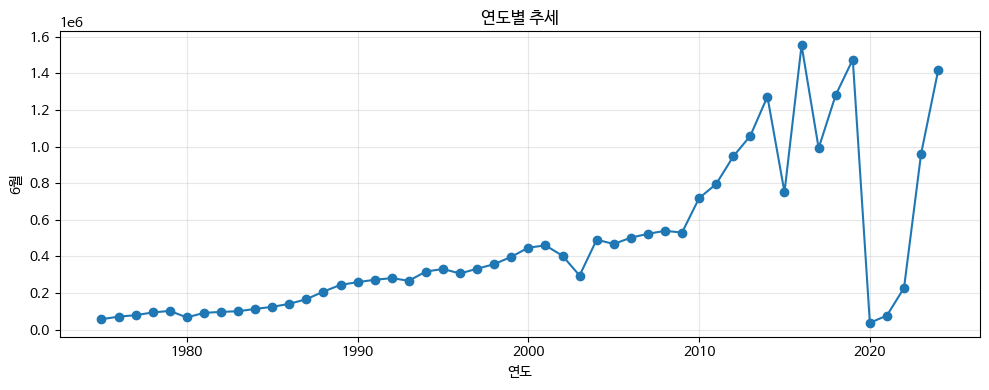

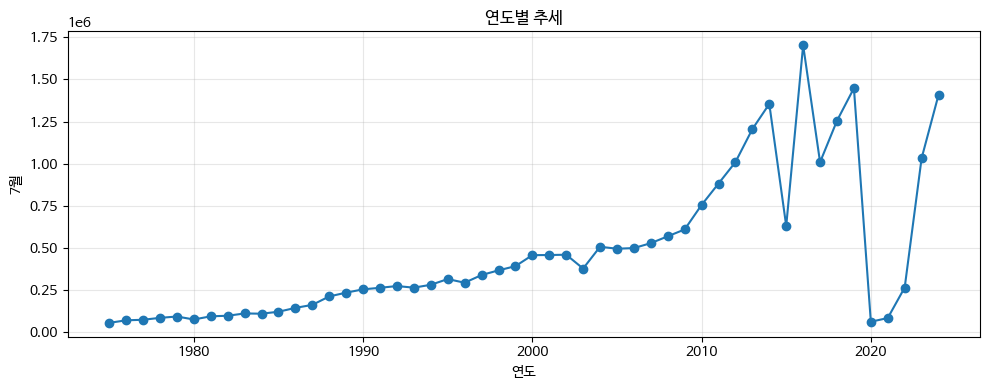

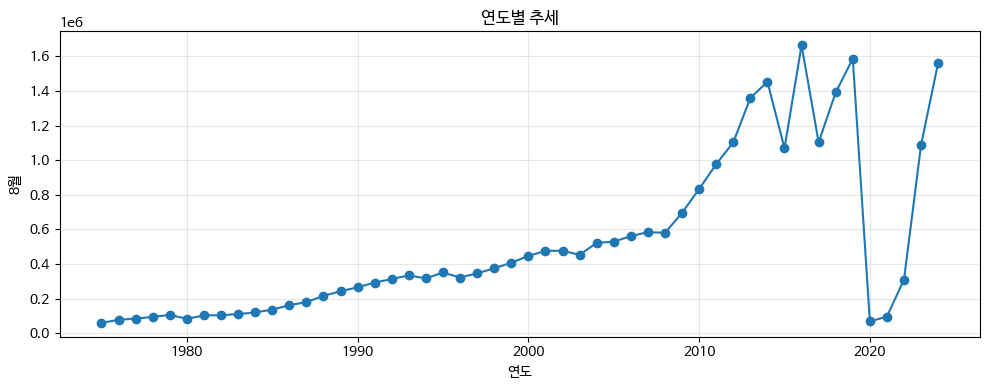

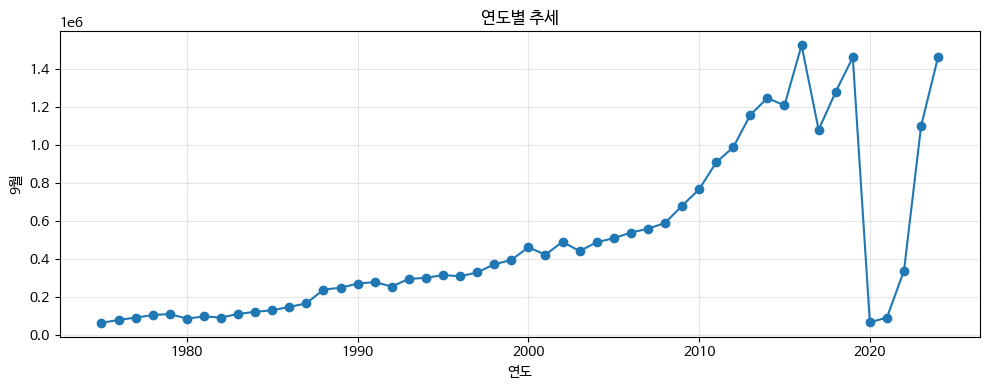

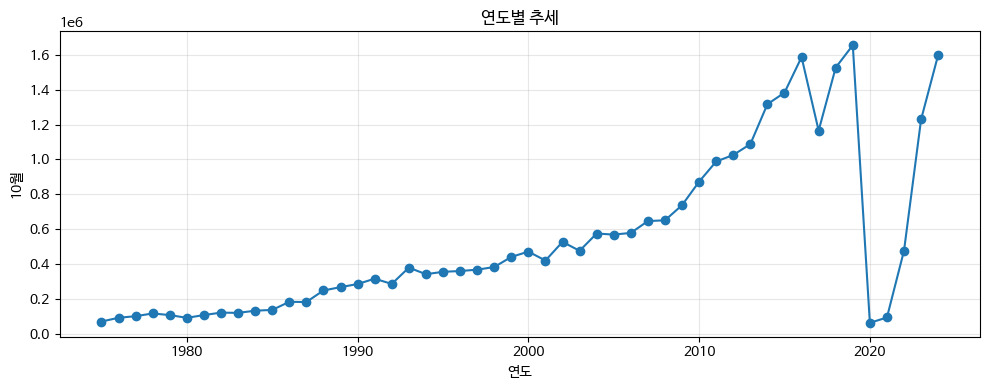

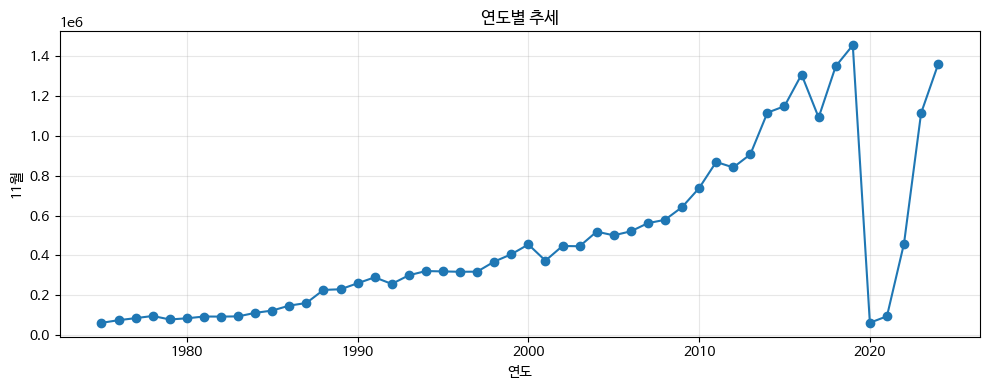

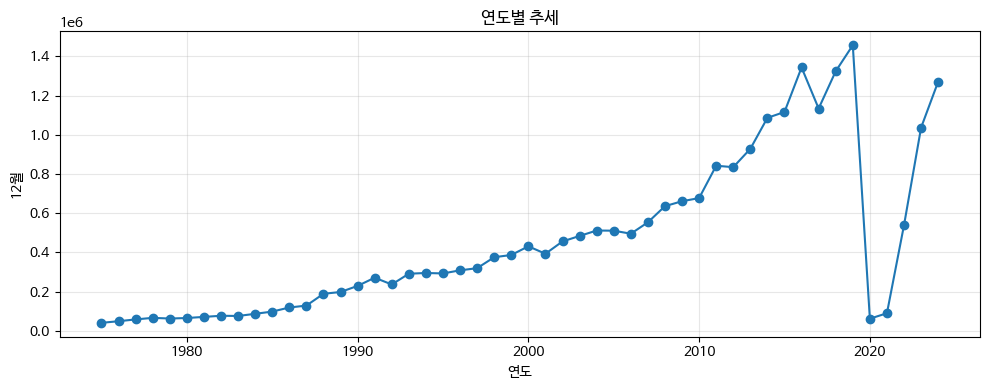

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 엑셀 파일 불러오기 - 헤더 없이 전체 데이터를 불러와서 헤더 행을 직접 지정
path = "/content/연도별통계(1975-2024).xlsx"
raw_df = pd.read_excel(path, header=None)

# 2. 실제 컬럼 이름이 있는 행을 찾아서 헤더로 설정
#    "연  도"가 포함된 행을 찾습니다. (실제 헤더는 raw_df.iloc[4]에 있습니다)
new_columns = raw_df.iloc[4] # 헤더 행 인덱스를 4로 수정
df = raw_df[5:].copy() # 데이터 시작 행 인덱스를 5로 수정
df.columns = new_columns # 새로운 컬럼 이름 지정

# 불필요한 'Year' 행 제거 (영문 헤더가 데이터로 들어와 있을 경우)
# '연  도' 컬럼을 찾아서 처리
if '연  도' in df.columns:
    df = df[df["연  도"] != "Year"].copy()
else:
    # 만약 '연  도' 컬럼이 정확히 일치하지 않는다면, 유사한 컬럼을 찾아 처리하거나 오류를 발생시킬 수 있습니다.
    # 예를 들어, 공백 문자가 다를 경우를 대비하여 컬럼 이름을 정규화하거나, '연'을 포함하는 컬럼을 찾습니다.
    year_col = [col for col in df.columns if isinstance(col, str) and '연' in col and '도' in col]
    if year_col:
        df.rename(columns={year_col[0]: '연  도'}, inplace=True)
        df = df[df["연  도"] != "Year"].copy()
    else:
        raise KeyError("연도 정보를 포함하는 컬럼을 찾을 수 없습니다.")

# 3. 연도 및 수치형 데이터로 형 변환
#   - '연  도'는 문자열이므로 정수형 연도 컬럼 '연도'로 새로 만듦
df["연도"] = pd.to_numeric(df["연  도"], errors="coerce")

#   - 나머지 수치형 컬럼들을 전부 숫자로 변환
value_cols = [c for c in df.columns if c not in ["연  도", "연도"]]
for col in value_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 4. 연도 기준 오름차순 정렬 (혹시라도 순서가 뒤섞인 경우 대비)
df = df.sort_values("연도")

# 5. 연도별 각 수치 데이터 시각화
#    - 각 지표(계, 성장률, 1월~12월)를 각각 하나의 그래프로 그림
years = df["연도"]

for col in value_cols:
    plt.figure(figsize=(10, 4))
    plt.plot(years, df[col], marker="o")
    plt.xlabel("연도")
    plt.ylabel(col)
    plt.title("연도별 추세")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import os

# ==========================================
# 1. 데이터 준비 (엑셀 파일 경로 설정)
# ==========================================
# 분석할 엑셀 파일의 경로를 지정해주세요.
file_path = '/content/연도별통계(1975-2024).xlsx'

def load_and_train_model_from_excel(path):
    """엑셀 파일을 로드하고 선형 회귀 모델을 학습시키는 함수"""
    try:
        # 엑셀 파일 로드
        # sheet_name=None을 주면 모든 시트를 딕셔너리 형태로 가져옵니다.
        # 특정 시트 이름을 안다면 sheet_name='방한 외래관광객' 처럼 지정하는 것이 정확합니다.
        xls = pd.read_excel(path, sheet_name=None, engine='openpyxl')

        target_df = None

        # '방한 외래관광객'이나 'Inbound' 키워드가 있는 시트를 찾거나,
        # 시트가 하나라면 그 시트를 사용합니다.
        for sheet_name, df in xls.items():
            if '방한' in sheet_name or '외래' in sheet_name or 'Inbound' in sheet_name:
                target_df = df
                print(f"'{sheet_name}' 시트 데이터를 사용합니다.")
                break

        # 자동으로 못 찾은 경우 첫 번째 시트 사용
        if target_df is None:
            first_sheet = list(xls.keys())[0]
            target_df = xls[first_sheet]
            print(f"시트를 특정하지 못해 첫 번째 시트('{first_sheet}')를 사용합니다.")

        # -------------------------------------------------------
        # 데이터 전처리 (헤더 찾기 및 정리)
        # -------------------------------------------------------
        header_row = 0
        # 데이터프레임의 앞부분을 훑어서 'Year'와 '계(Total)'가 있는 행을 헤더로 지정
        for i, row in target_df.head(15).iterrows():
            row_str = row.astype(str).values
            if (any('Year' in s for s in row_str) or any('연' in s for s in row_str)) and \
               (any('Total' in s for s in row_str) or any('계' in s for s in row_str)):
                header_row = i + 1 # 엑셀은 인덱스가 0부터 시작하지만 read_excel에서 header 지정시 편의를 위해 조정
                break

        # 헤더를 다시 지정하여 읽기 (해당 시트만 다시 로드)
        # 위에서 찾은 시트 이름을 사용
        sheet_to_load = [k for k, v in xls.items() if v.equals(target_df)][0]
        df = pd.read_excel(path, sheet_name=sheet_to_load, header=header_row, engine='openpyxl')

        # 컬럼명 정리
        df.columns = [str(c).replace('\n', '').strip() for c in df.columns]

        # 'Year', 'Total' 컬럼 찾기
        year_col = next((c for c in df.columns if 'Year' in c or '연' in c), None)
        total_col = next((c for c in df.columns if 'Total' in c or '계' in c), None)

        if not year_col or not total_col:
            print("필요한 컬럼(연도, 계)을 찾을 수 없습니다.")
            return None

        df = df[[year_col, total_col]].copy()
        df.columns = ['Year', 'Total']

        # 숫자 변환 및 결측치 제거
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        df['Total'] = df['Total'].astype(str).str.replace(',', '').replace('-', '')
        df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
        df = df.dropna()

        # -------------------------------------------------------
        # 모델 학습
        # -------------------------------------------------------
        X = df[['Year']]
        y = df['Total']

        model = LinearRegression()
        model.fit(X, y)

        return model

    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {path}")
        return None
    except Exception as e:
        print(f"오류 발생: {e}")
        return None

# 모델 학습 실행
model = load_and_train_model_from_excel(file_path)

if model:
    print("="*40)
    print("방한 외래관광객 수 예측 프로그램 (엑셀 버전)")
    print("="*40)

    while True:
        try:
            input_str = input("예측하고 싶은 연도를 입력하세요 (예: 2025, 종료하려면 'q'): ")

            if input_str.lower() == 'q':
                print("프로그램을 종료합니다.")
                break

            target_year = int(input_str)

            if target_year < 2025:
                print("2025년 이후의 연도를 입력해주세요.")
                continue

            prediction = model.predict([[target_year]])[0]

            print(f"▶ {target_year}년 예상 방한 외래관광객 수: 약 {int(prediction):,} 명")
            print("-" * 40)

        except ValueError:
            print("올바른 숫자를 입력해주세요.")
else:
    print("모델 생성 실패. 파일 경로와 내용을 확인해주세요.")

'방한 외래관광객' 시트 데이터를 사용합니다.
방한 외래관광객 수 예측 프로그램 (엑셀 버전)
예측하고 싶은 연도를 입력하세요 (예: 2025, 종료하려면 'q'): 2030


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


▶ 2030년 예상 방한 외래관광객 수: 약 13,564,549 명
----------------------------------------
예측하고 싶은 연도를 입력하세요 (예: 2025, 종료하려면 'q'): q
프로그램을 종료합니다.
